# Wildfire → Solar · M4 — Loss & Metrics (the compound-Poisson Monte Carlo)

**Peril:** Wildfire · **Layer:** M4 (loss & metrics) · assets: Hayhurst (low-fire) + Matrix (high-fire).

The finale of the solar cell. M1 gave the **frequency** (`λ`), M3 the **conditional severity** (per-class
loss given a fire). M4 assembles them into **annual loss vectors** via the **shared compound-Poisson Monte
Carlo** (reused from hail), then reads **EAL / VaR / PML / TVaR** off the **sampled** distribution, as **% of
TIV**. *This is the layer the old repo broke* — so the known-answer checks + the Method-0 contrast matter most.

> Plan: [`docs/plans/wildfire/m4_loss_metrics.md`](../../../../docs/plans/wildfire/m4_loss_metrics.md) ·
> Engine: reused from hail M4 (modular-from-day-one) · Frequency: [DD-W7](../../../../docs/plans/wildfire/decisions.md)
> (Poisson(λ), site-conditioned — no spatial factor).

## Engine reuse + the wildfire wiring

The hail engine ports verbatim; only the **per-year sampling** changes for a site-conditioned, pre-integrated
peril: **`N ~ Poisson(λ)`** fires/yr (λ from M1 — *no* `p_hit` thinning, *no* `λ_collection × p`), each fire
**samples a flame class** from M3's `prob_given_fire` and adds its **full conditional loss**; `fano = 1`.
`AEP` = annual total (capped at TIV), `OEP` = largest single fire. **LOTV:** sample occurrence + sample
severity — never `×λ`, never `×prob`. Run in **% of TIV**; dollars via TIV.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
N_YEARS = 300_000
SEED = 20260613
ASSETS = [("hayhurst_texas_solar", "Hayhurst Texas Solar", "baseline (low-fire)"),
          ("matrix_pleasant_valley", "Matrix Pleasant Valley", "proving (high-fire)")]

## 1 · Load the ingredients — λ (M1) + the per-class conditional loss (M3)

In [2]:
ING = {}
for slug, name, role in ASSETS:
    lam = json.loads((DATA_DIR / f"{slug}_wildfire_m1_manifest.json").read_text())["frequency_process_params"]["lambda_per_yr"]
    m3 = pd.read_parquet(DATA_DIR / f"{slug}_wildfire_m3_damage.parquet")
    m3s = json.loads((DATA_DIR / f"{slug}_wildfire_m3_summary.json").read_text())
    prob = m3["prob_given_fire"].to_numpy(float); prob = prob / prob.sum()        # renormalize (M3 stored to 6 dp)
    loss_pct = m3["cond_loss_pct_tiv"].to_numpy(float)                            # conditional loss given a fire, as FRACTION of TIV
    tiv = m3s["asset"]["tiv_usd"]; tiv_est = m3s["asset"]["tiv_estimated"]
    e_loss_given_fire = float((prob * loss_pct).sum())
    ING[slug] = {"name": name, "role": role, "lam": lam, "prob": prob, "loss_pct": loss_pct,
                 "tiv": tiv, "tiv_est": tiv_est, "e_loss_given_fire": e_loss_given_fire}
    print(f"{name:24s} ({role}): λ={lam:.5f}/yr (1 fire ≈ every {1/lam:,.0f} yr) · "
          f"E[loss|fire]={100*e_loss_given_fire:.2f}% TIV · TIV={'~$'+format(tiv,',.0f')+' (est)' if tiv_est else '$'+format(tiv,',.0f')}")

Hayhurst Texas Solar     (baseline (low-fire)): λ=0.00037/yr (1 fire ≈ every 2,703 yr) · E[loss|fire]=1.04% TIV · TIV=$36,778,400
Matrix Pleasant Valley   (proving (high-fire)): λ=0.04408/yr (1 fire ≈ every 23 yr) · E[loss|fire]=6.46% TIV · TIV=~$385,580,000 (est)


## 2 · The compound-Poisson Monte Carlo (run in % of TIV; cap = 100% TIV)

In [3]:
def run_mc(n_years, lam, loss_pct, prob, rng, cap=1.0):
    """Per year: N ~ Poisson(λ) fires; each fire samples a flame class ~ prob → its FULL conditional loss
    (fraction of TIV). AEP = annual total (capped at TIV); OEP = largest single fire. No ×λ, no ×prob."""
    counts = rng.poisson(lam, n_years)
    total = int(counts.sum())
    aep = np.zeros(n_years); oep = np.zeros(n_years)
    if total:
        cls = rng.choice(len(loss_pct), size=total, p=prob)        # sample flame class ~ P(class|fire)
        fire_loss = loss_pct[cls]                                  # full conditional loss on that fire
        year_id = np.repeat(np.arange(n_years), counts)
        aep = np.minimum(np.bincount(year_id, weights=fire_loss, minlength=n_years), cap)
        np.maximum.at(oep, year_id, fire_loss)
    return aep, oep


for slug, d in ING.items():
    rng = np.random.default_rng(SEED)
    d["aep"], d["oep"] = run_mc(N_YEARS, d["lam"], d["loss_pct"], d["prob"], rng)
    print(f"{d['name']:24s}: simulated {N_YEARS:,} yrs · zero-loss years {100*(d['aep']==0).mean():.2f}% · "
          f"EAL {100*d['aep'].mean():.4f}% TIV")

Hayhurst Texas Solar    : simulated 300,000 yrs · zero-loss years 99.96% · EAL 0.0004% TIV
Matrix Pleasant Valley  : simulated 300,000 yrs · zero-loss years 95.65% · EAL 0.2896% TIV


## 3 · Known-answer checks — confirm the engine before trusting the metrics *(basics-spot-on)*

In [4]:
for slug, d in ING.items():
    eal_analytic = d["lam"] * d["e_loss_given_fire"]               # λ · E[loss|fire] — mean, preserved
    zero_pois = float(np.exp(-d["lam"]))                          # P(0 fires) — every fire yields loss>0 (anchored DR>0)
    aep, oep = d["aep"], d["oep"]
    se = aep.std() / np.sqrt(N_YEARS)                             # MC standard error of the mean — large at small λ (rare-event noise)
    checks = [
        (f"EAL ≈ λ·E[loss|fire]   {100*aep.mean():.4f}% vs {100*eal_analytic:.4f}% TIV  (±4·SE={100*4*se:.4f}%)",
         abs(aep.mean() - eal_analytic) <= max(0.04 * eal_analytic, 4 * se) + 1e-12),   # statistical tol — rare events are MC-noisy
        (f"zero-loss ≈ exp(−λ)    {(aep==0).mean():.4f} vs {zero_pois:.4f}", abs((aep==0).mean()-zero_pois) < 0.005),
        ("AEP ≥ OEP every year", bool((aep + 1e-12 >= oep).all())),
    ]
    print(f"\n{d['name']} ({d['role']}):")
    for nm, ok in checks:
        print(f"  [{'PASS' if ok else 'FAIL'}] {nm}")
    assert all(ok for _, ok in checks), f"known-answer check failed for {slug}"
print("\nall known-answer checks pass ✓ (fano=1 → Poisson; NegBin deferred — clustering/portfolio, DD-W7)")


Hayhurst Texas Solar (baseline (low-fire)):
  [PASS] EAL ≈ λ·E[loss|fire]   0.0004% vs 0.0004% TIV  (±4·SE=0.0003%)
  [PASS] zero-loss ≈ exp(−λ)    0.9996 vs 0.9996
  [PASS] AEP ≥ OEP every year

Matrix Pleasant Valley (proving (high-fire)):
  [PASS] EAL ≈ λ·E[loss|fire]   0.2896% vs 0.2849% TIV  (±4·SE=0.0160%)
  [PASS] zero-loss ≈ exp(−λ)    0.9565 vs 0.9569
  [PASS] AEP ≥ OEP every year

all known-answer checks pass ✓ (fano=1 → Poisson; NegBin deferred — clustering/portfolio, DD-W7)


## 4 · The annual loss distribution — a spike at zero + a tail (the shape *is* the risk)

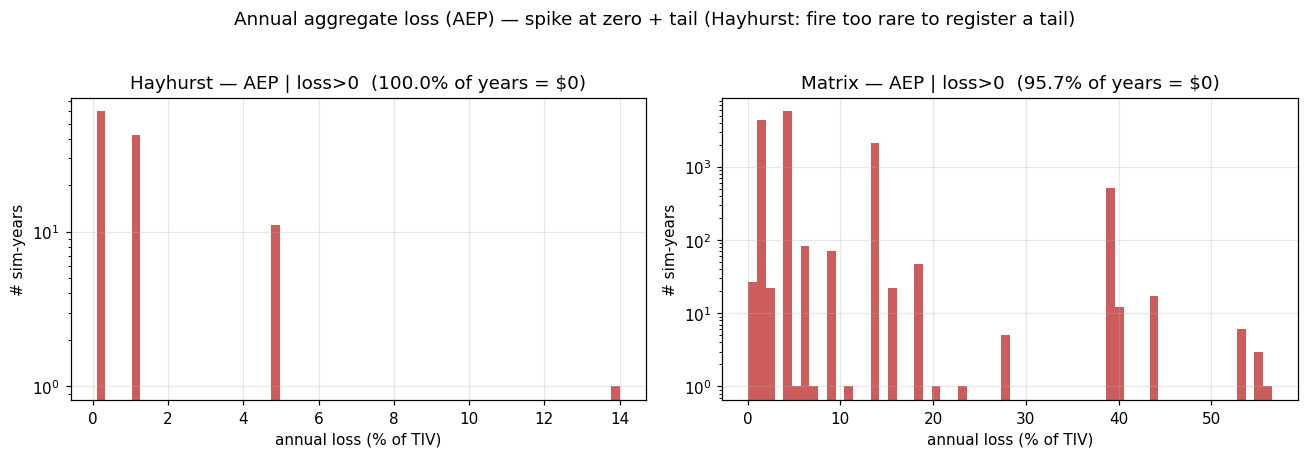

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (slug, d) in zip(axes, ING.items()):
    nz = d["aep"][d["aep"] > 0] * 100
    if nz.size:
        ax.hist(nz, bins=60, color="indianred")
    ax.set(title=f"{d['name'].split()[0]} — AEP | loss>0  ({100*(d['aep']==0).mean():.1f}% of years = $0)",
           xlabel="annual loss (% of TIV)", ylabel="# sim-years"); ax.set_yscale("log")
fig.suptitle("Annual aggregate loss (AEP) — spike at zero + tail (Hayhurst: fire too rare to register a tail)", y=1.03)
fig.tight_layout(); plt.show()

## 5 · Risk metrics — off the sampled vectors, as % of TIV (and $)

AEP = annual aggregate; OEP = annual max single fire. PML at return period *T* = the (1−1/T) percentile.

In [6]:
def metrics_pct(aep, oep):
    v99 = np.quantile(aep, 0.99)
    return {"EAL": aep.mean(), "VaR95 (PML20)": np.quantile(aep, 0.95), "VaR99 (PML100)": v99,
            "VaR99.6 (PML250)": np.quantile(aep, 0.996), "TVaR99": aep[aep >= v99].mean() if (aep >= v99).any() else v99,
            "OEP-PML100": np.quantile(oep, 0.99), "zero_loss_fraction": (aep == 0).mean()}

for slug, d in ING.items():
    M = metrics_pct(d["aep"], d["oep"]); d["M"] = M
    rows = [{"metric": k,
             "% of TIV": (f"{100*v:.2f}%" if k != "zero_loss_fraction" else f"{100*v:.2f}%"),
             "$": ("—" if k == "zero_loss_fraction" else f"${v*d['tiv']/1e6:,.3f}M")} for k, v in M.items()]
    print(f"\n{d['name']} ({d['role']}) · λ={d['lam']:.5f}/yr · TIV={'~$'+format(d['tiv'],',.0f')+' (est)' if d['tiv_est'] else '$'+format(d['tiv'],',.0f')}")
    print(pd.DataFrame(rows).to_string(index=False))


Hayhurst Texas Solar (baseline (low-fire)) · λ=0.00037/yr · TIV=$36,778,400
            metric % of TIV       $
               EAL    0.00% $0.000M
     VaR95 (PML20)    0.00% $0.000M
    VaR99 (PML100)    0.00% $0.000M
  VaR99.6 (PML250)    0.00% $0.000M
            TVaR99    0.00% $0.000M
        OEP-PML100    0.00% $0.000M
zero_loss_fraction   99.96%       —

Matrix Pleasant Valley (proving (high-fire)) · λ=0.04408/yr · TIV=~$385,580,000 (est)
            metric % of TIV        $
               EAL    0.29%  $1.117M
     VaR95 (PML20)    0.00%  $0.000M
    VaR99 (PML100)    4.75% $18.302M
  VaR99.6 (PML250)   14.01% $54.029M
            TVaR99    9.44% $36.413M
        OEP-PML100    4.75% $18.302M
zero_loss_fraction   95.65%        —


## 6 · The Method-0 contrast — why the old repo's tail was wrong

Method-0 replaces each year's stochastic outcome by its expectation (`λ·E[loss|fire]`, a constant) →
preserves EAL, but its "VaR99" ≈ EAL, far below the true tail. The occurrence + severity variance the tail
is made of is gone.

In [7]:
for slug, d in ING.items():
    m0 = d["lam"] * d["e_loss_given_fire"]
    v99 = d["M"]["VaR99 (PML100)"]
    ratio = v99 / max(m0, 1e-12)
    print(f"{d['name']:24s}: Method-0 EAL={100*m0:.4f}% = its 'VaR99' (constant) · CORRECT MC VaR99={100*v99:.2f}% TIV "
          f"→ Method-0 understates 1-in-100 by ~{ratio:.0f}×" if v99 > 0 else
          f"{d['name']:24s}: Method-0 EAL={100*m0:.4f}% · MC VaR99=0 (fire too rare for a 1-in-100 tail) — EAL agrees, tail is ~0 either way")

Hayhurst Texas Solar    : Method-0 EAL=0.0004% · MC VaR99=0 (fire too rare for a 1-in-100 tail) — EAL agrees, tail is ~0 either way
Matrix Pleasant Valley  : Method-0 EAL=0.2849% = its 'VaR99' (constant) · CORRECT MC VaR99=4.75% TIV → Method-0 understates 1-in-100 by ~17×


## 7 · The low-vs-high payoff — the model behaving across the contrast

In [8]:
cmp = pd.DataFrame([{
    "asset": d["name"], "role": d["role"], "λ/yr": round(d["lam"], 5),
    "zero-loss yrs": f"{100*d['M']['zero_loss_fraction']:.1f}%",
    "EAL %TIV": f"{100*d['M']['EAL']:.4f}%", "EAL $/yr": f"${d['M']['EAL']*d['tiv']:,.0f}",
    "VaR99 %TIV": f"{100*d['M']['VaR99 (PML100)']:.2f}%", "PML250 %TIV": f"{100*d['M']['VaR99.6 (PML250)']:.2f}%",
} for d in ING.values()]).set_index("asset")
print("Low-vs-high wildfire risk — the validation payoff:\n")
print(cmp.to_string())
print("\n→ Hayhurst (desert): EAL negligible, tail ≈ 0 (a fire is ~1-in-2700 yr). "
      "Matrix (sagebrush): a real EAL + a material tail. The same engine, the right answer at both ends.")

Low-vs-high wildfire risk — the validation payoff:

                                       role     λ/yr zero-loss yrs EAL %TIV    EAL $/yr VaR99 %TIV PML250 %TIV
asset                                                                                                         
Hayhurst Texas Solar    baseline (low-fire)  0.00037        100.0%  0.0004%        $151      0.00%       0.00%
Matrix Pleasant Valley  proving (high-fire)  0.04408         95.7%  0.2896%  $1,116,583      4.75%      14.01%

→ Hayhurst (desert): EAL negligible, tail ≈ 0 (a fire is ~1-in-2700 yr). Matrix (sagebrush): a real EAL + a material tail. The same engine, the right answer at both ends.


## 8 · Persist the M4 artifacts

In [9]:
for slug, d in ING.items():
    M = d["M"]
    pd.DataFrame({"sim_year": np.arange(N_YEARS), "aep_pct_tiv": d["aep"], "oep_pct_tiv": d["oep"],
                  "aep_usd": d["aep"] * d["tiv"], "oep_usd": d["oep"] * d["tiv"]}) \
        .to_parquet(DATA_DIR / f"{slug}_wildfire_m4_annual_vectors.parquet", index=False)
    summary = {
        "layer": "M4_loss_metrics", "peril": "wildfire", "asset": {"slug": slug, "name": d["name"], "role": d["role"]},
        "engine": "shared compound-Poisson Monte-Carlo (reused from hail); Poisson(λ) fires, class-sampled severity",
        "n_sim_years": N_YEARS, "frequency": "poisson", "lambda_per_yr": d["lam"], "fano_factor": 1.0,
        "tiv_usd": d["tiv"], "tiv_estimated": d["tiv_est"],
        "loss_basis": "gross physical only (no deductibles/limits/BI — deferred)",
        "metrics_pct_of_tiv": {k: round(100 * float(v), 4) for k, v in M.items() if k != "zero_loss_fraction"},
        "metrics_usd": {k: round(float(v) * d["tiv"], 2) for k, v in M.items() if k != "zero_loss_fraction"},
        "zero_loss_fraction": round(float(M["zero_loss_fraction"]), 5),
        "known_answer_checks": "pass (EAL≈λ·E[loss|fire]; zero-loss≈exp(−λ); AEP≥OEP)",
        "metrics_status": "REAL but APPROXIMATE — curve-limited (DD-W8 anchored approximate curve; 6-class "
                          "discrete severity coarse deep tail AW-24; d=10m; single-site). NOT record-limited (λ FSim-pre-integrated).",
        "provenance": {"plan": "docs/plans/wildfire/m4_loss_metrics.md", "from": f"{slug}_wildfire_m3_damage.parquet + m1 λ"},
    }
    (DATA_DIR / f"{slug}_wildfire_m4_metrics.json").write_text(json.dumps(summary, indent=2, default=str))
    print(f"wrote {slug}: annual vectors + metrics  ·  EAL={100*M['EAL']:.4f}% TIV (${M['EAL']*d['tiv']:,.0f}/yr) · VaR99={100*M['VaR99 (PML100)']:.2f}% TIV")

wrote hayhurst_texas_solar: annual vectors + metrics  ·  EAL=0.0004% TIV ($151/yr) · VaR99=0.00% TIV
wrote matrix_pleasant_valley: annual vectors + metrics  ·  EAL=0.2896% TIV ($1,116,583/yr) · VaR99=4.75% TIV


## 9 · Findings — M0→M4 wildfire × solar is complete

- **The engine reused cleanly** (modular-from-day-one): the hail compound-MC ran wildfire with only the
  sampling swapped (Poisson(λ) fires + class-sampled severity, no p_hit). Known-answer checks pass; Method-0
  re-demonstrates the tail collapse — the old-repo failure, structurally avoided.
- **The low-vs-high contrast pays off in metrics:** Hayhurst ≈ 0 (fire too rare), Matrix a real EAL + tail.
- **Real but APPROXIMATE** (curve-limited — DD-W8 approximate anchored curve, 6-class discrete severity,
  d=10 m, single-site). *Not* record-limited (λ is FSim-pre-integrated). Don't quote as final.
- **Next:** the **wind cell** (`wildfire/wind/` M2–M4 on the shared M0/M1 — per-turbine, hub-height
  attenuation, the 3 wind curves), then the cross-peril close-out.